Exploração dos Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("dark_background")

In [2]:
caminho = r"C:\Users\ailto\Downloads\Planilhas e Fundamentos .xlsx"
aba = "Stores"

In [3]:
df = pd.read_excel(caminho, sheet_name=aba,skiprows=5,
                   usecols=["Business","Country","UF","State","City","Opening date",
                            "Shopping Mall / Street"])

df

,Business,Opening date,Country,UF,State,City,Shopping Mall / Street
0,Youcom,2025-11-01,Brazil,DF,Distrito Federal,Brasília,Shopping Mall
1,Camicado,2025-11-01,Brazil,DF,Distrito Federal,Brasília,Shopping Mall
2,Renner,2025-10-30,Brazil,SP,São Paulo,Americana,Shopping Mall
3,Youcom,2025-10-30,Brazil,SP,São Paulo,Americana,Shopping Mall
4,Youcom,2025-10-24,Brazil,DF,Distrito Federal,Brasília,Shopping Mall
...,...,...,...,...,...,...,...
778,Renner,1980-09-01,Brazil,RS,Rio Grande do Sul,Santa Maria,Street
779,Renner,1977-11-01,Brazil,RS,Rio Grande do Sul,Porto Alegre,Street
780,Renner,1976-04-10,Brazil,RS,Rio Grande do Sul,Canoas,Shopping Mall
781,Renner,1970-12-04,Brazil,RS,Rio Grande do Sul,Porto Alegre,Shopping Mall


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Business                783 non-null    str           
 1   Opening date            783 non-null    datetime64[us]
 2   Country                 783 non-null    str           
 3   UF                      783 non-null    str           
 4   State                   783 non-null    str           
 5   City                    783 non-null    str           
 6   Shopping Mall / Street  783 non-null    str           
dtypes: datetime64[us](1), str(6)
memory usage: 79.9 KB


In [5]:
df = df[(df["Business"] == "Renner") &
        (df["Country"] == "Brazil")] 
df

,Business,Opening date,Country,UF,State,City,Shopping Mall / Street
2,Renner,2025-10-30,Brazil,SP,São Paulo,Americana,Shopping Mall
8,Renner,2025-09-18,Brazil,MG,Minas Gerais,Passos,Street
16,Renner,2025-05-16,Brazil,GO,Goiás,Caldas Novas,Shopping Mall
17,Renner,2025-03-12,Brazil,RO,Rondônia,Vilhena,Shopping Mall
18,Renner,2024-12-04,Brazil,PR,Paraná,Toledo,Street
...,...,...,...,...,...,...,...
778,Renner,1980-09-01,Brazil,RS,Rio Grande do Sul,Santa Maria,Street
779,Renner,1977-11-01,Brazil,RS,Rio Grande do Sul,Porto Alegre,Street
780,Renner,1976-04-10,Brazil,RS,Rio Grande do Sul,Canoas,Shopping Mall
781,Renner,1970-12-04,Brazil,RS,Rio Grande do Sul,Porto Alegre,Shopping Mall


In [6]:
pib_municipal = pd.read_excel(r"C:\Users\ailto\Downloads\base_de_dados_2010_2023_xlsx\PIB dos Municípios - base de dados 2010-2023.xlsx")

pib_municipal = pib_municipal.rename(columns={"Nome da Grande Região" : "Regiao",
                                              "Sigla da Unidade da Federação":"UF",
                                              "Nome da Unidade da Federação":"Estado",
                                              "Nome do Município":"Municipio",
                                              "Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)":"PIB_PC"})

pib_municipal

,Ano,Regiao,UF,Estado,Municipio,PIB_PC
0,2010,Norte,RO,Rondônia,Alta Floresta D'Oeste,10731.18
1,2010,Norte,RO,Rondônia,Ariquemes,15103.86
2,2010,Norte,RO,Rondônia,Cabixi,11033.62
3,2010,Norte,RO,Rondônia,Cacoal,15095.15
4,2010,Norte,RO,Rondônia,Cerejeiras,13037.06
...,...,...,...,...,...,...
77960,2023,Centro-oeste,GO,Goiás,Vianópolis,61175.68
77961,2023,Centro-oeste,GO,Goiás,Vicentinópolis,77280.98
77962,2023,Centro-oeste,GO,Goiás,Vila Boa,47887.65
77963,2023,Centro-oeste,GO,Goiás,Vila Propício,76390.22


In [7]:
pib_municipal = pib_municipal.rename(columns={"Municipio":"City"})

pib_municipal = pib_municipal[pib_municipal["Ano"] == 2023]
pib_municipal = pib_municipal[["City","PIB_PC"]]

pib_municipal

,City,PIB_PC
72395,Alta Floresta D'Oeste,48680.68
72396,Ariquemes,45271.91
72397,Cabixi,56219.79
72398,Cacoal,44292.79
72399,Cerejeiras,63334.77
...,...,...
77960,Vianópolis,61175.68
77961,Vicentinópolis,77280.98
77962,Vila Boa,47887.65
77963,Vila Propício,76390.22


In [12]:
populacao_municipios = pd.read_excel(r"C:\Users\ailto\Downloads\base_de_dados_2010_2023_xlsx\PIB dos Municípios - base de dados 2010-2023.xlsx", sheet_name="POPULACAO")

In [14]:
populacao_municipios = populacao_municipios.rename(columns={"NOME DO MUNICÍPIO":"City"})

In [15]:
populacao_municipios

,UF,City,POPULAÇÃO ESTIMADA
0,RO,Alta Floresta D'Oeste,22787
1,RO,Ariquemes,109170
2,RO,Cabixi,5664
3,RO,Cacoal,98280
4,RO,Cerejeiras,16966
...,...,...,...
5566,GO,Vianópolis,15644
5567,GO,Vicentinópolis,9175
5568,GO,Vila Boa,4145
5569,GO,Vila Propício,6028


In [18]:
dados_municipios = populacao_municipios.merge(pib_municipal,on="City")

dados_municipios

,UF,City,POPULAÇÃO ESTIMADA,PIB_PC
0,RO,Alta Floresta D'Oeste,22787,48680.68
1,RO,Ariquemes,109170,45271.91
2,RO,Cabixi,5664,56219.79
3,RO,Cacoal,98280,44292.79
4,RO,Cerejeiras,16966,63334.77
...,...,...,...,...
6217,GO,Vianópolis,15644,61175.68
6218,GO,Vicentinópolis,9175,77280.98
6219,GO,Vila Boa,4145,47887.65
6220,GO,Vila Propício,6028,76390.22


In [19]:
dados_lojas_economia = dados_municipios.merge(df, on = ["City", "UF"])

dados_lojas_economia

,UF,City,POPULAÇÃO ESTIMADA,PIB_PC,Business,Opening date,Country,State,Shopping Mall / Street
0,RO,Cacoal,98280,44292.79,Renner,2021-04-05,Brazil,Rondônia,Shopping Mall
1,RO,Porto Velho,517709,55170.11,Renner,2008-10-30,Brazil,Rondônia,Shopping Mall
2,RO,Vilhena,109651,53382.85,Renner,2025-03-12,Brazil,Rondônia,Shopping Mall
3,AC,Rio Branco,389001,35533.25,Renner,2011-11-08,Brazil,Acre,Shopping Mall
4,AC,Rio Branco,389001,28642.74,Renner,2011-11-08,Brazil,Acre,Shopping Mall
...,...,...,...,...,...,...,...,...,...
476,DF,Brasília,2996899,129790.44,Renner,2009-06-25,Brazil,Distrito Federal,Shopping Mall
477,DF,Brasília,2996899,129790.44,Renner,2007-10-23,Brazil,Distrito Federal,Shopping Mall
478,DF,Brasília,2996899,129790.44,Renner,2001-05-08,Brazil,Distrito Federal,Shopping Mall
479,DF,Brasília,2996899,129790.44,Renner,2000-11-16,Brazil,Distrito Federal,Shopping Mall


In [20]:
dados_lojas_economia.groupby("Shopping Mall / Street")["Shopping Mall / Street"].size()/len(dados_lojas_economia)

Shopping Mall / Street
Shopping Mall    0.87526
Street           0.12474
Name: Shopping Mall / Street, dtype: float64

In [21]:
dados_lojas_economia.sort_values("POPULAÇÃO ESTIMADA")

,UF,City,POPULAÇÃO ESTIMADA,PIB_PC,Business,Opening date,Country,State,Shopping Mall / Street
393,RS,Garibaldi,35563,103842.78,Renner,2021-04-15,Brazil,Rio Grande do Sul,Shopping Mall
394,RS,Gramado,41705,88848.11,Renner,2017-09-20,Brazil,Rio Grande do Sul,Street
433,RS,Torres,43344,43963.72,Renner,2021-10-23,Brazil,Rio Grande do Sul,Shopping Mall
210,SP,Campos do Jordão,47956,41444.19,Renner,2024-08-22,Brazil,São Paulo,Street
380,RS,Canela,50715,40038.38,Renner,2023-08-03,Brazil,Rio Grande do Sul,Street
...,...,...,...,...,...,...,...,...,...
283,SP,São Paulo,11904961,93156.23,Renner,2017-08-29,Brazil,São Paulo,Street
288,SP,São Paulo,11904961,93156.23,Renner,2015-11-11,Brazil,São Paulo,Street
272,SP,São Paulo,11904961,93156.23,Renner,2023-11-22,Brazil,São Paulo,Shopping Mall
287,SP,São Paulo,11904961,93156.23,Renner,2016-04-28,Brazil,São Paulo,Shopping Mall


In [22]:
dados_lojas_economia.sort_values("PIB_PC")

,UF,City,POPULAÇÃO ESTIMADA,PIB_PC,Business,Opening date,Country,State,Shopping Mall / Street
455,MT,Várzea Grande,318922,12375.88,Renner,2015-11-17,Brazil,Mato Grosso,Shopping Mall
439,MS,Campo Grande,962883,13934.63,Renner,2013-08-15,Brazil,Mato Grosso do Sul,Shopping Mall
441,MS,Campo Grande,962883,13934.63,Renner,2005-04-20,Brazil,Mato Grosso do Sul,Shopping Mall
440,MS,Campo Grande,962883,13934.63,Renner,2011-05-25,Brazil,Mato Grosso do Sul,Shopping Mall
436,MS,Campo Grande,962883,14017.60,Renner,2013-08-15,Brazil,Mato Grosso do Sul,Shopping Mall
...,...,...,...,...,...,...,...,...,...
198,SP,Barueri,333737,226391.22,Renner,2011-04-28,Brazil,São Paulo,Shopping Mall
197,SP,Barueri,333737,226391.22,Renner,2011-11-30,Brazil,São Paulo,Shopping Mall
196,SP,Barueri,333737,226391.22,Renner,2017-04-06,Brazil,São Paulo,Shopping Mall
203,SP,Cajamar,98365,312708.11,Renner,2023-08-09,Brazil,São Paulo,Shopping Mall


In [25]:
from scipy import stats

# Distribuições completas
pib_municipios = dados_municipios["PIB_PC"].dropna()
pib_lojas = dados_lojas_economia["PIB_PC"].dropna()

print(f"Média PIB municípios: R$ {pib_municipios.mean():,.2f}")
print(f"Média PIB lojas:      R$ {pib_lojas.mean():,.2f}")
print(f"Mediana PIB municípios: R$ {pib_municipios.median():,.2f}")
print(f"Mediana PIB lojas:      R$ {pib_lojas.median():,.2f}")

# Teste de Mann-Whitney (não-paramétrico)
u_stat, p_valor = stats.mannwhitneyu(pib_lojas, pib_municipios, alternative="greater")
print(f"\nMann-Whitney U: {u_stat:.0f}")
print(f"p-valor: {p_valor:.2e}")
print("→ Renner abre lojas em municípios com PIB per capita significativamente maior" 
      if p_valor < 0.05 else "→ Sem diferença significativa")

Média PIB municípios: R$ 40,069.69
Média PIB lojas:      R$ 64,157.53
Mediana PIB municípios: R$ 29,695.80
Mediana PIB lojas:      R$ 59,773.04

Mann-Whitney U: 2277946
p-valor: 9.70e-82
→ Renner abre lojas em municípios com PIB per capita significativamente maior


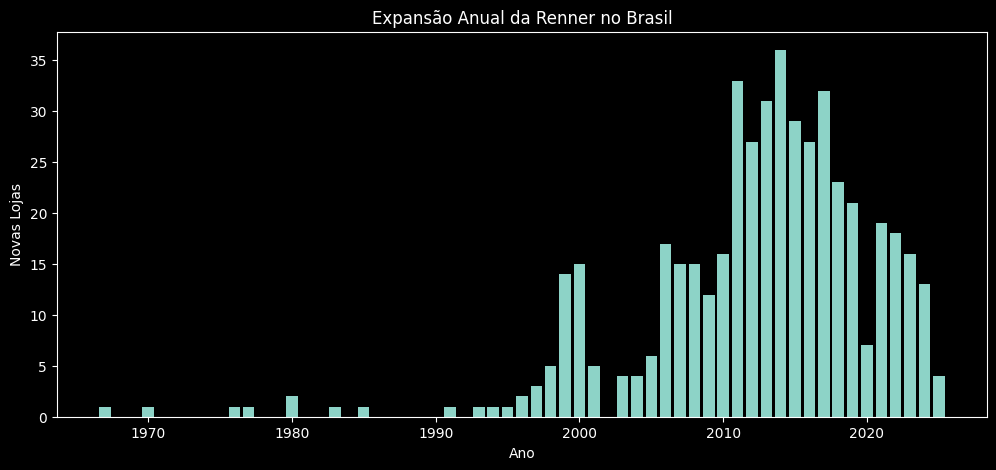

In [ ]:
dados_lojas_economia["Ano"] = dados_lojas_economia["Opening date"].dt.year
abertura_lojas = dados_lojas_economia.groupby("Ano").size().reset_index(name="Novas_lojas")

fig, ax = plt.subplots(figsize=(12,5))
ax.bar(abertura_lojas["Ano"], abertura_lojas["Novas_lojas"])
ax.set_xlabel("Ano")
ax.set_ylabel("Novas Lojas")
ax.set_title("Expansão Anual da Renner no Brasil")
plt.show()

<Axes: xlabel='UF'>

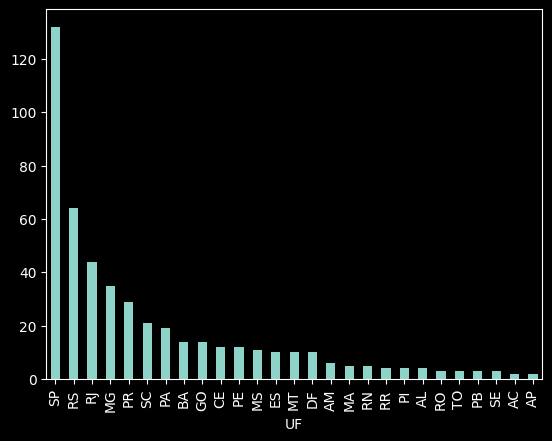

In [48]:
dados_lojas_economia["UF"].value_counts().plot(kind="bar")

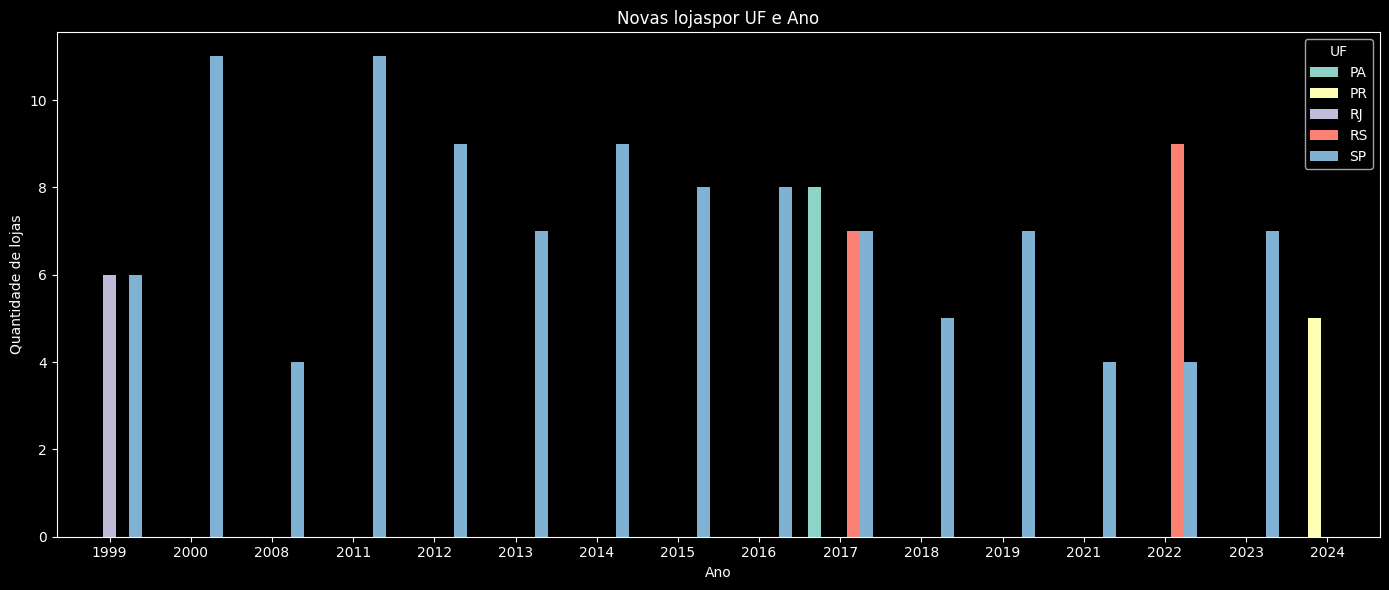

In [ ]:
novas_lojas_uf = dados_lojas_economia.groupby(["UF","Ano"]).size().reset_index(name="Quantidade de lojas").sort_values("Quantidade de lojas", ascending=False).head(20)

pivot = novas_lojas_uf.pivot(index="Ano", columns="UF", values="Quantidade de lojas")

fig, ax = plt.subplots(figsize=(14,6))
pivot.plot(kind="bar", ax=ax, width=0.8)

ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de lojas")
ax.set_title("Novas lojaspor UF e Ano")
ax.legend(title="UF", bbox_to_anchor=(1,1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
lojas_cidade = dados_lojas_economia.groupby(["UF","City"]).size().reset_index(name="n_lojas")

base_cidades = dados_municipios.merge(
    lojas_cidade, on=["UF","City"], how="left"
).fillna({"n_lojas":0})

oportunidades = base_cidades[
    (base_cidades["POPULAÇÃO ESTIMADA"] > 200_000) &
    (base_cidades["PIB_PC"] > base_cidades["PIB_PC"].median()) &
    (base_cidades["n_lojas"] == 0)
].sort_values("POPULAÇÃO ESTIMADA", ascending=False).head(20)

oportunidades

,UF,City,POPULAÇÃO ESTIMADA,PIB_PC,n_lojas
3895,SP,Guarujá,294871,40107.77,0.0
1229,RN,Parnamirim,271713,30107.02,0.0
3848,SP,Embu das Artes,259788,68971.96,0.0
1094,CE,Maracanaú,251613,57738.06,0.0
3901,SP,Hortolândia,248842,93660.54,0.0
3942,SP,Itapevi,242995,67220.40,0.0
3294,MG,Santa Luzia,230382,30155.78,0.0
3292,MG,Santa Luzia,230382,38333.11,0.0
1717,PE,Cabo de Santo Agostinho,218049,78144.03,0.0
209,PA,Castanhal,209126,32862.91,0.0


Renner prefere municípios ricos? Sim

Quando a Expansão acelerou? 2010-2020

Onde estão as lojas? 80% em Shopping

Quais estados mais penetrados? São Paulo, Rio Grande do Sul e Rio de Janeiro

Onde falta Renner com perfil ideal? 10 cidades com potencial

